
------STAGE 1------
Interior points : 1353
Boundary points : 600
Total unknowns = 572

Gauss-Newton Iteration

Iter 0: ||R|| = 4.24e+01
Iter 1: ||R|| = 5.76e-01
Iter 2: ||R|| = 5.37e-03
Iter 3: ||R|| = 2.52e-06
Iter 4: ||R|| = 2.46e-06

Stage 1 time: 0.93 s

Global Errors before exact BC enforcement
RMS error  = 3.20e-09
Linf error = 1.25e-08

------STAGE 2------

Reduced Newton

Reduced Iter 0: ||R|| = 2.38e-04
Reduced Iter 1: ||R|| = 1.39e-06

Stage 2 time: 0.41 s


RMS error   = 4.26e-10
Linf error = 3.41e-09

Max BC error  = 1.01e-27
Mean BC error = 1.68e-30


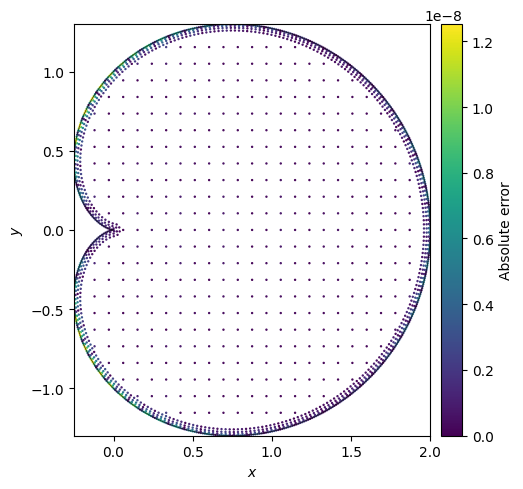

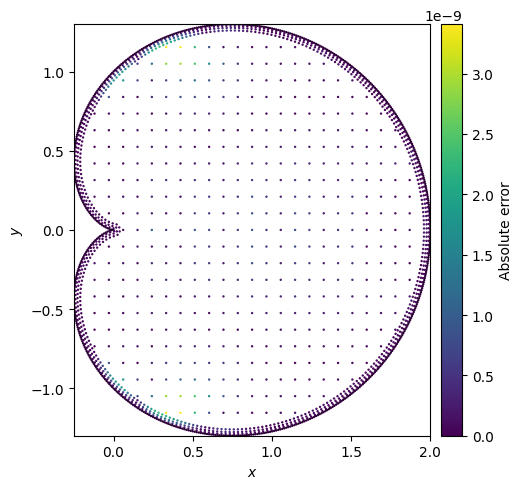

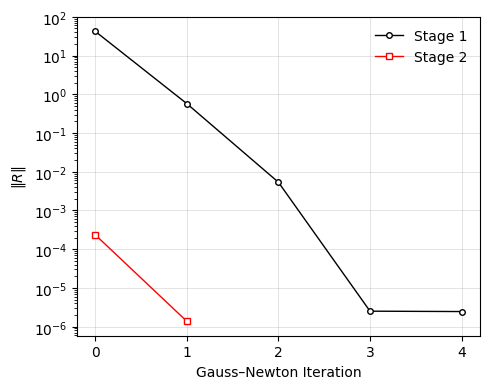

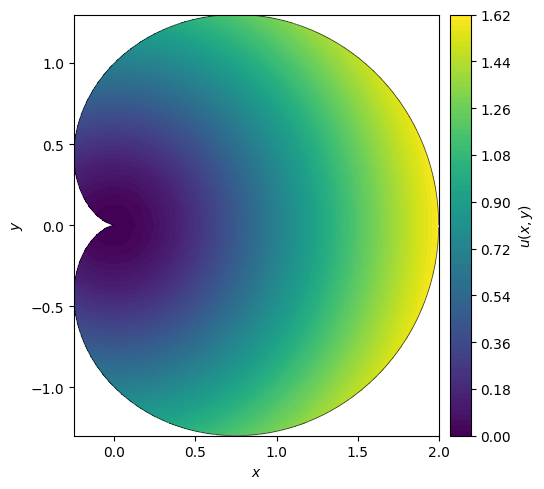

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from numpy.polynomial.legendre import legval, legder
from scipy.linalg import lu_factor, lu_solve
from scipy.interpolate import griddata
from shapely.geometry import Point, Polygon

print("")
print("------STAGE 1------")


# ==========================================================
# 1. Load Cardioid Points
# ==========================================================
interior_pts = np.load(
    "data/cardioid_interior_points.npy"
)

boundary_pts = np.load(
    "data/cardioid_boundary_points.npy"
)

xi_int, yi_int = interior_pts[:, 0], interior_pts[:, 1]
xi_b, yi_b     = boundary_pts[:, 0], boundary_pts[:, 1]

print("Interior points :", interior_pts.shape[0])
print("Boundary points :", boundary_pts.shape[0])


# ==========================================================
# 2. Bounding Box Scaling (Anisotropic)
# ==========================================================
x_all_tmp = np.concatenate([xi_int, xi_b])
y_all_tmp = np.concatenate([yi_int, yi_b])

xmin, xmax = x_all_tmp.min(), x_all_tmp.max()
ymin, ymax = y_all_tmp.min(), y_all_tmp.max()

sx = 2.0 / (xmax - xmin)
sy = 2.0 / (ymax - ymin)


def scale_x(x):

    return sx * (x - xmin) - 1.0


def scale_y(y):

    return sy * (y - ymin) - 1.0


# ==========================================================
# 3. Shifted Legendre Basis
# ==========================================================
Nx = 22
Ny = 26

n_unknowns = Nx * Ny

print("Total unknowns =", n_unknowns)


# ==========================================================
# 2D Tensor Product Basis Matrix
# ==========================================================
def legendre_matrix_2d(x, y, Nx, Ny):

    x = scale_x(x)
    y = scale_y(y)

    cols = []

    for i in range(Nx):

        Px = legval(x, [0] * i + [1])

        for j in range(Ny):

            Py = legval(y, [0] * j + [1])

            cols.append(Px * Py)

    return np.vstack(cols).T


# ==========================================================
# Second Derivative Matrices
# ==========================================================
def legendre_derivative_matrices_2d(x, y, Nx, Ny):

    x = scale_x(x)
    y = scale_y(y)

    dxx_cols = []
    dyy_cols = []

    for i in range(Nx):

        ci = [0] * i + [1]

        d2ci = legder(legder(ci))

        Px   = legval(x, ci)
        d2Px = legval(x, d2ci)

        for j in range(Ny):

            cj = [0] * j + [1]

            d2cj = legder(legder(cj))

            Py   = legval(y, cj)
            d2Py = legval(y, d2cj)

            dxx_cols.append((sx**2) * d2Px * Py)
            dyy_cols.append((sy**2) * Px * d2Py)

    return np.vstack(dxx_cols).T, np.vstack(dyy_cols).T


# ==========================================================
# Assemble Basis Matrices
# ==========================================================
start1 = time.time()

P_int = legendre_matrix_2d(
    xi_int,
    yi_int,
    Nx,
    Ny
)

P_b = legendre_matrix_2d(
    xi_b,
    yi_b,
    Nx,
    Ny
)

dxx_int, dyy_int = legendre_derivative_matrices_2d(
    xi_int,
    yi_int,
    Nx,
    Ny
)


# ==========================================================
# 4. Exact Solution and RHS
# ==========================================================
def u_exact(x, y):

    return np.log(1 + x**2 + y**2)


def rhs_pde(x, y):

    r2 = x**2 + y**2

    lap = 4 / (1 + r2)**2

    return lap + (1 + r2)


RHS_int = rhs_pde(xi_int, yi_int)

U_b_exact = u_exact(xi_b, yi_b)


# ==========================================================
# 5. Initial Linear Solve
# ==========================================================
A_int = dxx_int + dyy_int + P_int

R_int = RHS_int - 1

A_lin = np.vstack([
    A_int,
    P_b
])

R_lin = np.concatenate([
    R_int,
    U_b_exact
])

beta = np.linalg.lstsq(
    A_lin,
    R_lin,
    rcond=None
)[0]


res_hist_stage1 = []
res_hist_stage2 = []


# ==========================================================
# 6. Gauss-Newton Iteration
# ==========================================================
print("\nGauss-Newton Iteration\n")

tol = 1e-10

maxit = 5

for it in range(maxit):

    u_int = P_int @ beta

    R_int = (
        dxx_int @ beta
        + dyy_int @ beta
        + np.exp(u_int)
        - RHS_int
    )

    R_b = P_b @ beta - U_b_exact

    R = np.concatenate([R_int, R_b])

    res = np.linalg.norm(R)

    res_hist_stage1.append(res)

    print(f"Iter {it}: ||R|| = {res:.2e}")

    if res < tol:
        break

    exp_u = np.exp(u_int)

    J_int = (
        dxx_int
        + dyy_int
        + exp_u[:, None] * P_int
    )

    J = np.vstack([
        J_int,
        P_b
    ])

    delta = np.linalg.lstsq(
        J,
        -R,
        rcond=None
    )[0]

    beta += delta


# ==========================================================
# 7. All-Point Matrices
# ==========================================================
x_all = np.concatenate([xi_int, xi_b])
y_all = np.concatenate([yi_int, yi_b])

P_all = legendre_matrix_2d(
    x_all,
    y_all,
    Nx,
    Ny
)


# ==========================================================
# 8. Global Error Before Exact BC Enforcement
# ==========================================================
u_before = P_all @ beta

u_exact_all = u_exact(x_all, y_all)

end1 = time.time()

print("")
print("Stage 1 time:", np.round((end1 - start1), 2), "s")
print("")

abs_error_before = np.abs(
    u_before - u_exact_all
)

print("Global Errors before exact BC enforcement")

print(f"RMS error  = {np.sqrt(np.mean(abs_error_before**2)):.2e}")
print(f"Linf error = {np.max(abs_error_before):.2e}")


# ==========================================================
# STEP 2
# ==========================================================
print("")
print("------STAGE 2------")


# ==========================================================
# 9. Gaussian RBF
# ==========================================================
start2 = time.time()


def rbf_matrix(x, y, cx, cy, lam):

    dx = x[:, None] - cx[None, :]
    dy = y[:, None] - cy[None, :]

    return np.exp(-lam * (dx**2 + dy**2))


lam = 1500.0

cx, cy = xi_b.copy(), yi_b.copy()

A_bc = rbf_matrix(
    xi_b,
    yi_b,
    cx,
    cy,
    lam
)

LU, piv = lu_factor(A_bc)

AinvPb = lu_solve(
    (LU, piv),
    P_b
)


dx = xi_int[:, None] - cx[None, :]
dy = yi_int[:, None] - cy[None, :]

r2 = dx**2 + dy**2

Phi = np.exp(-lam * r2)

Phi_int = Phi

Phi_xx = (
    4 * lam**2 * dx**2 - 2 * lam
) * Phi

Phi_yy = (
    4 * lam**2 * dy**2 - 2 * lam
) * Phi


correction = Phi_int @ AinvPb

effective_P = P_int - correction

L_reduced = (
    dxx_int
    + dyy_int
    + Phi_xx @ (-AinvPb)
    + Phi_yy @ (-AinvPb)
)


# ==========================================================
# 10. Reduced Newton Iteration
# ==========================================================
def residual(beta):

    u_b_pred = P_b @ beta

    q = lu_solve(
        (LU, piv),
        U_b_exact - u_b_pred
    )

    u = P_int @ beta + Phi_int @ q

    uxx = dxx_int @ beta + Phi_xx @ q
    uyy = dyy_int @ beta + Phi_yy @ q

    R = uxx + uyy + np.exp(u) - RHS_int

    return R, q, u


print("\nReduced Newton\n")

for it in range(2):

    R, q, u = residual(beta)

    res = np.linalg.norm(R)

    res_hist_stage2.append(res)

    print(f"Reduced Iter {it}: ||R|| = {res:.2e}")

    if res < tol:
        break

    J = (
        L_reduced
        + np.exp(u)[:, None] * effective_P
    )

    delta = np.linalg.lstsq(
        J,
        -R,
        rcond=None
    )[0]

    beta += delta


# ==========================================================
# Final q
# ==========================================================
u_b_pred = P_b @ beta

q = lu_solve(
    (LU, piv),
    U_b_exact - u_b_pred
)


# ==========================================================
# 11. Final Error
# ==========================================================
Phi_all = rbf_matrix(
    x_all,
    y_all,
    cx,
    cy,
    lam
)

u_all = P_all @ beta + Phi_all @ q

end2 = time.time()

print("")
print("Stage 2 time:", np.round((end2 - start2), 2), "s")
print("")

abs_error_after = np.abs(
    u_all - u_exact_all
)

print("")
print(f"RMS error   = {np.sqrt(np.mean(abs_error_after**2)):.2e}")
print(f"Linf error = {np.max(abs_error_after):.2e}")


# ==========================================================
# Boundary Condition Verification
# ==========================================================
psi_boundary = u_b_pred + A_bc @ q

dirichlet_error = np.abs(
    psi_boundary - U_b_exact
)

print("")
print(f"Max BC error  = {np.max(dirichlet_error):.2e}")
print(f"Mean BC error = {np.mean(dirichlet_error):.2e}")


# ==========================================================
# Absolute Error Plots
# ==========================================================
err_before = abs_error_before
err_after  = abs_error_after


# ==========================================================
# Color Limits
# ==========================================================
vmin_before = 0.0
vmax_before = err_before.max()

vmin_after  = 0.0
vmax_after  = err_after.max()


# ==========================================================
# Figure 1: Error BEFORE BC Enforcement
# ==========================================================
fig1, ax1 = plt.subplots(figsize=(6, 5))

ax1.plot(
    xi_b,
    yi_b,
    color="black",
    linewidth=0.6,
    alpha=0.7,
    zorder=3
)

sc1 = ax1.scatter(
    x_all,
    y_all,
    c=err_before,
    s=0.5,
    vmin=vmin_before,
    vmax=vmax_before,
    cmap='viridis'
)

ax1.set_aspect(
    'equal',
    adjustable='box'
)

ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$y$")

ax1.set_xlim(x_all.min(), x_all.max())
ax1.set_ylim(y_all.min(), y_all.max())


# ==========================================================
# Colorbar
# ==========================================================
cbar1 = fig1.colorbar(
    sc1,
    ax=ax1,
    shrink=1,
    pad=0.02
)

cbar1.set_label("Absolute error")


# ==========================================================
# Save Figure
# ==========================================================
plt.tight_layout()

plt.savefig(
    "fig2d_1.pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15
)

plt.show()

plt.close(fig1)


# ==========================================================
# Figure 2: Error AFTER BC Enforcement
# ==========================================================
fig2, ax2 = plt.subplots(figsize=(6, 5))

ax2.plot(
    xi_b,
    yi_b,
    color="black",
    linewidth=0.6,
    alpha=0.7,
    zorder=3
)

sc2 = ax2.scatter(
    x_all,
    y_all,
    c=err_after,
    s=0.5,
    vmin=vmin_after,
    vmax=vmax_after,
    cmap='viridis'
)

ax2.set_aspect(
    'equal',
    adjustable='box'
)

ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$y$")

ax2.set_xlim(x_all.min(), x_all.max())
ax2.set_ylim(y_all.min(), y_all.max())


# ==========================================================
# Colorbar
# ==========================================================
cbar2 = fig2.colorbar(
    sc2,
    ax=ax2,
    shrink=1,
    pad=0.02
)

cbar2.set_label("Absolute error")


# ==========================================================
# Save Figure
# ==========================================================
plt.tight_layout()

plt.savefig(
    "fig2d_2.pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15
)

plt.show()

plt.close(fig2)

# ==========================================================
# Convergence Plot
# ==========================================================

iters1 = np.arange(len(res_hist_stage1))
iters2 = np.arange(len(res_hist_stage2))

max_iter = max(
    len(res_hist_stage1),
    len(res_hist_stage2)
)


# ==========================================================
# Create Figure
# ==========================================================
plt.figure(figsize=(5, 4))


# ==========================================================
# Stage 1 Residual History
# ==========================================================
plt.semilogy(
    iters1,
    res_hist_stage1,
    marker='o',
    markersize=4,
    markerfacecolor='white',
    markeredgewidth=1,
    linewidth=1,
    color='black',
    label='Stage 1'
)


# ==========================================================
# Stage 2 Residual History
# ==========================================================
plt.semilogy(
    iters2,
    res_hist_stage2,
    marker='s',
    markersize=4,
    markerfacecolor='white',
    markeredgewidth=1,
    linewidth=1,
    color='red',
    label='Stage 2'
)


# ==========================================================
# Axis Labels
# ==========================================================
plt.xlabel("Gauss–Newton Iteration")

plt.ylabel(r"$\|R\|$")


# ==========================================================
# Integer Iteration Ticks
# ==========================================================
plt.xticks(np.arange(max_iter))


# ==========================================================
# Grid and Legend
# ==========================================================
plt.grid(
    True,
    linestyle='-',
    linewidth=0.5,
    alpha=0.5
)

plt.legend(frameon=False)


# ==========================================================
# Save Figure
# ==========================================================
plt.tight_layout()

plt.savefig(
    "fig2d_res.pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15
)

plt.show()

#=========================================================
# EXACT SOLUTION PLOT
# ==========================================================
# Exact Solution
# ==========================================================
U_exact_all = np.log(
    1.0 + x_all**2 + y_all**2
)


# ==========================================================
# Create Structured Grid
# ==========================================================
Nxg = 400
Nyg = 400

xg = np.linspace(
    x_all.min(),
    x_all.max(),
    Nxg
)

yg = np.linspace(
    y_all.min(),
    y_all.max(),
    Nyg
)

Xg, Yg = np.meshgrid(xg, yg)


# ==========================================================
# Interpolate Solution onto Grid
# ==========================================================
Ug_linear = griddata(
    (x_all, y_all),
    U_exact_all,
    (Xg, Yg),
    method="linear"
)

Ug_nearest = griddata(
    (x_all, y_all),
    U_exact_all,
    (Xg, Yg),
    method="nearest"
)


# ==========================================================
# Replace NaNs Using Nearest Interpolation
# ==========================================================
Ug = np.where(
    np.isnan(Ug_linear),
    Ug_nearest,
    Ug_linear
)


# ==========================================================
# Construct Cardioid Polygon
# ==========================================================
domain_polygon = Polygon(
    np.column_stack([xi_b, yi_b])
)


# ==========================================================
# Mask Exterior Points
# ==========================================================
mask = np.zeros(
    Xg.shape,
    dtype=bool
)

for i in range(Xg.shape[0]):

    for j in range(Xg.shape[1]):

        if not domain_polygon.contains(
            Point(Xg[i, j], Yg[i, j])
        ):

            mask[i, j] = True


Ug = np.ma.array(
    Ug,
    mask=mask
)


# ==========================================================
# Contour Plot
# ==========================================================
fig, ax = plt.subplots(figsize=(6, 5))


# ==========================================================
# Filled Contours
# ==========================================================
cf = ax.contourf(
    Xg,
    Yg,
    Ug,
    levels=80,
    cmap="viridis"
)


# ==========================================================
# Boundary Curve
# ==========================================================
ax.plot(
    xi_b,
    yi_b,
    color="black",
    linewidth=0.6,
    alpha=0.7,
    zorder=3
)


# ==========================================================
# Axis Settings
# ==========================================================
ax.set_aspect(
    "equal",
    adjustable="box"
)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")


# ==========================================================
# Axis Limits
# ==========================================================
xmin, xmax = x_all.min(), x_all.max()
ymin, ymax = y_all.min(), y_all.max()

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)


# ==========================================================
# Colorbar
# ==========================================================
cbar = fig.colorbar(
    cf,
    ax=ax,
    shrink=1,
    pad=0.02
)

cbar.set_label(r"$u(x,y)$")


# ==========================================================
# Save Figure
# ==========================================================
plt.tight_layout()

plt.savefig(
    "fig2_exact.pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15
)

plt.show()

plt.close(fig)